<a href="https://colab.research.google.com/github/alanapooler827/554Homework6/blob/main/ST554_HW6_Pooler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Alana Pooler
<br>
ST 554 Homework 6

The purpose of this homework is to get a little more practice with SQL and gain some practice with creating classes.

# Part I - More Practice Querying a Database

1. Connect to the database and then look at all of the tables in the database (use read_sql() from pandas to have this returned as a data frame).

First, import necessary libraries

In [8]:
import sqlite3
import pandas as pd

In [9]:
# make connection to database file
con = sqlite3.connect("lahman_1871-2022.sqlite")

# write query to get the schema information
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''

# return result as a data frame
schema_df = pd.read_sql(get_schema, con)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


2. Using SQL, construct a table of hall of fame pitchers (any hall of famer that pitched) that gives the playerID and their total (sum) for GS, G, W, L, IPOuts, CG, SHO, and SV columns. The summing can be done in pandas or in the SQL call.

In [10]:
sql = '''
  SELECT
    p.playerID,
    sum(p.GS) AS total_GS,
    sum(p.G) as total_G,
    sum(p.W) as total_W,
    sum(p.L) as total_L,
    sum(p.IPOuts) as total_IPOuts,
    sum(p.CG) as total_CG,
    sum(p.SHO) as total_SHO,
    sum(p.SV) as total_SV
  FROM Pitching AS p
  LEFT JOIN HallOfFame as h
    on p.playerID = h.playerID
  WHERE h.inducted = 'Y'
  GROUP BY p.playerID
  '''
hof_pitchers = pd.read_sql(sql, con)
hof_pitchers

,playerID,total_GS,total_G,total_W,total_L,total_IPOuts,total_CG,total_SHO,total_SV
0,alexape01,599,696,373,208,15570,437,90,32
1,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,1,1,0,1,12,0,0,0
3,bendech01,334,459,212,127,9051,255,40,34
4,blylebe01,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11
104,wrighge01,0,3,0,1,15,0,0,0
105,wrighha01,8,36,4,4,301,0,0,14
106,wynnea01,612,691,300,244,13692,290,49,15


3. For all of the hall of fame pitchers, use SQL to create a table of their batting statistics. Namely, the playerID and their total (sum) for AB, R, H, HR, RBI, BB, and SO. The summing can be done in pandas or in the SQL call.

In [11]:
sql = '''
  SELECT
    p.playerID,
    sum(b.AB) AS total_AB,
    sum(b.R) as total_R,
    sum(b.H) as total_H,
    sum(b.HR) as total_HR,
    sum(b.RBI) as total_RBI,
    sum(b.BB) as total_BB,
    sum(b.SO) as total_SO
  FROM Pitching AS p
  LEFT JOIN HallOfFame as h
    on p.playerID = h.playerID
  LEFT JOIN Batting as b
    on p.playerID = b.playerID
  WHERE h.inducted = 'Y'
  GROUP BY p.playerID
  '''
hof_pitchers_stats = pd.read_sql(sql, con)
hof_pitchers_stats

,playerID,total_AB,total_R,total_H,total_HR,total_RBI,total_BB,total_SO
0,alexape01,38010,3234,7938,231,3423,1617,5796
1,ansonca01,20562,3998,6870,194,4150,1968,660
2,becklja01,9551,1603,2938,87,1581,616,526
3,bendech01,18352,1632,3888,96,1856,1200,2288
4,blylebe01,10824,456,1416,0,600,120,4632
...,...,...,...,...,...,...,...,...
103,willivi01,19409,1391,3224,13,1092,1053,2587
104,wrighge01,5746,1330,1732,22,652,136,238
105,wrighha01,3252,732,896,16,452,148,56
106,wynnea01,39192,3128,8395,391,3979,3243,7590


4. Using pandas join the previous two tables together by pitcher. (If you want, try to do all of this via SQL! Not required though, feel free to use pd.merge() if you'd like)

Using SQL:

In [ ]:
sql = '''
  SELECT
    p.playerID,
    sum(p.GS) AS total_GS,
    sum(p.G) as total_G,
    sum(p.W) as total_W,
    sum(p.L) as total_L,
    sum(p.IPOuts) as total_IPOuts,
    sum(p.CG) as total_CG,
    sum(p.SHO) as total_SHO,
    sum(p.SV) as total_SV,
    sum(b.AB) AS total_AB,
    sum(b.R) as total_R,
    sum(b.H) as total_H,
    sum(b.HR) as total_HR,
    sum(b.RBI) as total_RBI,
    sum(b.BB) as total_BB,
    sum(b.SO) as total_SO
  FROM Pitching AS p
  LEFT JOIN HallOfFame as h
    on p.playerID = h.playerID
  LEFT JOIN Batting as b
    on p.playerID = b.playerID
  WHERE h.inducted = 'Y'
  GROUP BY p.playerID
  '''
hof_pitchers_all_stats = pd.read_sql(sql, con)
hof_pitchers_all_stats

,playerID,total_GS,total_G,total_W,total_L,total_IPOuts,total_CG,total_SHO,total_SV,total_AB,total_R,total_H,total_HR,total_RBI,total_BB,total_SO
0,alexape01,12579,14616,7833,4368,326970,9177,1890,672,38010,3234,7938,231,3423,1617,5796
1,ansonca01,0,81,0,27,324,0,0,27,20562,3998,6870,194,4150,1968,660
2,becklja01,22,22,0,22,264,0,0,0,9551,1603,2938,87,1581,616,526
3,bendech01,5344,7344,3392,2032,144816,4080,640,544,18352,1632,3888,96,1856,1200,2288
4,blylebe01,16440,16608,6888,6000,357840,5808,1440,0,10824,456,1416,0,600,120,4632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,6123,6669,3237,2665,155844,5044,650,143,19409,1391,3224,13,1092,1053,2587
104,wrighge01,0,36,0,12,180,0,0,0,5746,1330,1732,22,652,136,238
105,wrighha01,56,252,28,28,2107,0,0,98,3252,732,896,16,452,148,56
106,wynnea01,14076,15893,6900,5612,314916,6670,1127,345,39192,3128,8395,391,3979,3243,7590


Using pandas:

In [13]:
hof_pitchers_all_stats2 = pd.merge(hof_pitchers, hof_pitchers_stats, on = 'playerID')
hof_pitchers_all_stats2

,playerID,total_GS,total_G,total_W,total_L,total_IPOuts,total_CG,total_SHO,total_SV,total_AB,total_R,total_H,total_HR,total_RBI,total_BB,total_SO
0,alexape01,599,696,373,208,15570,437,90,32,38010,3234,7938,231,3423,1617,5796
1,ansonca01,0,3,0,1,12,0,0,1,20562,3998,6870,194,4150,1968,660
2,becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581,616,526
3,bendech01,334,459,212,127,9051,255,40,34,18352,1632,3888,96,1856,1200,2288
4,blylebe01,685,692,287,250,14910,242,60,0,10824,456,1416,0,600,120,4632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11,19409,1391,3224,13,1092,1053,2587
104,wrighge01,0,3,0,1,15,0,0,0,5746,1330,1732,22,652,136,238
105,wrighha01,8,36,4,4,301,0,0,14,3252,732,896,16,452,148,56
106,wynnea01,612,691,300,244,13692,290,49,15,39192,3128,8395,391,3979,3243,7590


# Part II - Messing with Classes

5. In the previous homework we used a loop to repeatedly do simulations around the estimate of a sample slope.

We assume the following model for SLR:
$$Y_i = \beta_0 + \beta_i x_i + E_i$$

where the $E_i$ are assumed to be indendent and identically distributed from a Normal distribution with mean 0 and variance $\sigma^2$. Let's assume $\sigma^2$ = 1 for simplicity.

Instead of writing this simulation the way we did in the last homework, we'll design a Python class that encapsulates the simulation of the sampling distribution of the slope estimator!

Create a class called SLR_slope_simulator:
* Initialize the class using __init__ with arguments self, beta_0, beta_1, x, sigma, and seed
  * Create initial attributes of beta_0, beta_1, sigma, x, n, rng, and slopes (an empty list)
* Required Methods. Your class should include methods (not @classmethod, just methods that work on an already created instances of the class):
  * **generate_data** method that generates one dataset (returning x and y in whatever manner you deem fit, i.e. as an array, two arrays, etc.)
  * **fit_slope** method that takes in an x and y and fits the SLR model, returning the estimated slope
  * **run_simulations** method that takes in a number of simulations argument and uses the generate_data() and fit_slope() methods within a for loop. This should not return anything but should modify the slopes attribute (replaces it with an array of slope estimates)
  * **plot_sampling_distribution** method that checks if the slopes attribute has length greater than 0 (if it doesn't print a message that run_simulations() must be called first). If it is, it should produce a histogram of the slopes approximating the sampling distribution.
  * **find_prob** method that takes in a value and a sided argument. It should checks on the slopes attribute as above. If the length is bigger than 0, it should approximate the probability of being “above”, “below”, or “two-sided” (values for sided).
    * If sided is “above”, you should approximate the probability of being larger than the value.
    * If it is “below”, you should approximate the probability of being smaller than the value.
    * If it is “two-sided”, you should approximate the probability of being larger in absolute value

Import the script that contains the SLR slope simulator class

In [6]:
import slr_slope_simulator
import numpy as np

Test SLR slope simulator script

run_simulations() must be called first


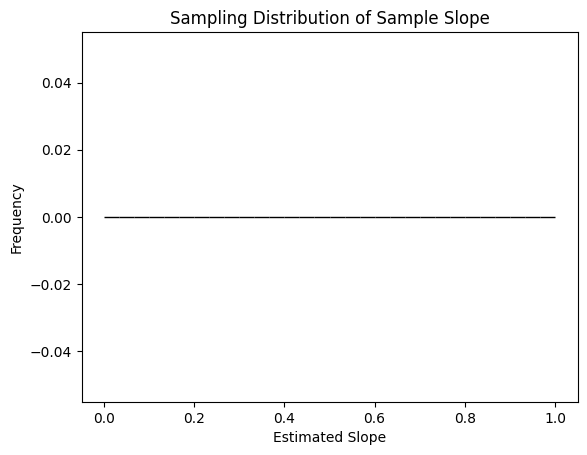

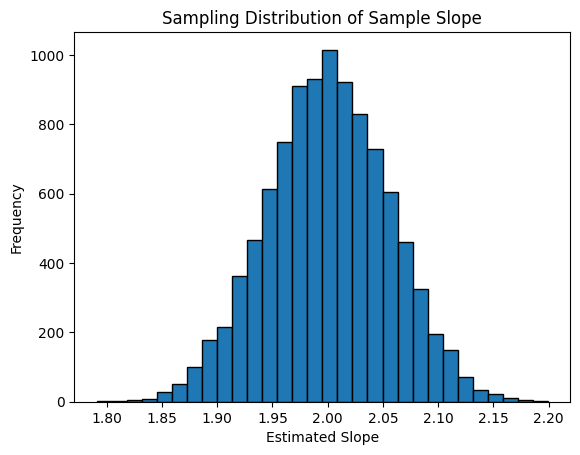

np.float64(0.0352)

In [7]:
# create x values to use in simulator
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)

sim = slr_slope_simulator.SLR_slope_simulator(beta_0 = 12, beta_1 = 2, x = x, sigma = 1, seed = 10)

# call plot_sampling_distribution() before run_simulation() to show error message
sim.plot_sampling_distribution()

# call run simulations
sim.run_simulations(10000)

# plot the sampling distribution
sim.plot_sampling_distribution()

# calculate the two-sided probability of sample slope being larger than 2.1
prob = sim.find_prob(2.1, 'two-sided')
print(f'Two-sided probability of sample slope being larger than 2.1: {prob}')